# Polynomial chaos expansions


In [1]:
import matplotlib.pyplot as plt
import numpy as np

import archimedes as arc

Before turning to the orbit-transfer case study, it's worth building intuition on two classic problems from the (generalized) polynomial chaos literature. Both have closed-form solutions, so — unlike the orbit-transfer example — you can check the gPCE approximation against an exact answer rather than only against Monte Carlo:

1. **Exponential decay with an uncertain rate constant** — a Gaussian input, Hermite basis, and a known analytic solution for both the output moments and the PCE coefficients themselves. This is the standard example used to introduce the method (Xiu & Karniadakis, 2002), because it makes the geometric convergence of gPCE vs. the $O(N^{-1/2})$ convergence of Monte Carlo completely explicit.
2. **The Ishigami function** — a uniform-input, strongly nonlinear benchmark from the sensitivity-analysis literature (Ishigami & Homma, 1990) with known closed-form Sobol' indices, letting us verify directly that the squared, normalized gPCE coefficients *are* the Sobol' decomposition, exactly as claimed at the end of this notebook.

With both of those working, we come back to the orbit-transfer dispersion problem, which is a more realistic black-box simulation without any closed-form solution to check against.

## 1. Setting up the representation

Say your uncertain inputs are collected into a vector of $d$ independent standard Gaussian random variables $\boldsymbol{\xi} = (\xi_1, \dots, \xi_d)$, and your output is $Y = f(\boldsymbol{\xi})$ for some (possibly expensive, black-box) model $f$. If $Y$ has finite variance, the Cameron–Martin theorem guarantees it has a convergent expansion in multivariate **Hermite polynomials**, which form a complete orthogonal basis for $L^2$ under Gaussian measure:

$$Y = f(\boldsymbol{\xi}) = \sum_{\alpha} c_\alpha \Psi_\alpha(\boldsymbol{\xi})$$

Here $\alpha = (\alpha_1, \dots, \alpha_d)$ is a multi-index and

$$\Psi_\alpha(\boldsymbol{\xi}) = \prod_{i=1}^{d} He_{\alpha_i}(\xi_i)$$

using the **probabilists' Hermite polynomials**: $He_0 = 1$, $He_1(x) = x$, $He_2(x) = x^2 - 1$, $He_3(x) = x^3 - 3x$, with recurrence $He_{n+1}(x) = x\,He_n(x) - n\,He_{n-1}(x)$.

The key structural fact is orthogonality with respect to the standard normal density $\varphi(x) = \frac{1}{\sqrt{2\pi}}e^{-x^2/2}$:

$$\mathbb{E}[He_m(\xi)\,He_n(\xi)] = \int He_m(x)He_n(x)\,\varphi(x)\,dx = n!\,\delta_{mn}$$

so in the multivariate case $\mathbb{E}[\Psi_\alpha \Psi_\beta] = \gamma_\alpha \,\delta_{\alpha\beta}$, with $\gamma_\alpha = \alpha! = \prod_i \alpha_i!$.

In practice you truncate to total degree $\le p$, leaving $P+1 = \binom{d+p}{p}$ terms — this truncation is really the only approximation being made at the representation level; everything else is about computing the coefficients accurately.

## 2. Determining the coefficients

Because $\{\Psi_\alpha\}$ is an orthogonal basis, each coefficient is just a projection — the same idea as a Fourier coefficient:

$$c_\alpha = \frac{\mathbb{E}[Y\,\Psi_\alpha(\boldsymbol{\xi})]}{\mathbb{E}[\Psi_\alpha^2(\boldsymbol{\xi})]} = \frac{1}{\alpha!}\int_{\mathbb{R}^d} f(\boldsymbol{\xi})\,\Psi_\alpha(\boldsymbol{\xi})\,\varphi(\boldsymbol{\xi})\,d\boldsymbol{\xi}$$

where $\varphi(\boldsymbol{\xi}) = \prod_i \varphi(\xi_i)$ is the joint standard Gaussian density. This is an exact formula, but the integral is generally not tractable analytically once $f$ is a real simulation — so for a non-intrusive approach you treat $f$ as a black box, evaluate it at a set of chosen points, and approximate the projection integral numerically. This is where quadrature comes in, and it's almost always the practical route.

## 3. Turning the projection into quadrature

Since the weight function $\varphi(\xi)$ is exactly the Gaussian weight, the natural quadrature rule is **Gauss–Hermite quadrature**.

**One dimension.** The "physicists'" Gauss–Hermite rule gives nodes/weights $(x_i, w_i)_{i=1}^n$ satisfying

$$\int_{-\infty}^{\infty} e^{-x^2} g(x)\,dx \approx \sum_{i=1}^n w_i\, g(x_i)$$

exact whenever $g$ is a polynomial of degree $\le 2n-1$. To match the standard-normal weight, substitute $\xi = \sqrt{2}\,x$:

$$\int f(\xi)\,\varphi(\xi)\,d\xi \approx \sum_{i=1}^n \frac{w_i}{\sqrt{\pi}}\, f(\sqrt{2}\,x_i)$$

So your quadrature nodes in $\xi$-space are $\xi_i = \sqrt{2}\,x_i$ with rescaled weights $w_i' = w_i/\sqrt{\pi}$ (these sum to 1, as a probability weight should).

**Multiple dimensions.** For independent Gaussian inputs, build a **tensor-product** rule: pick $n$ points per dimension, and the full multivariate grid is

$$\{\boldsymbol{\xi}^{(k)}\} = \{(\xi_{i_1}, \dots, \xi_{i_d})\}, \qquad W^{(k)} = \prod_{j=1}^d w'_{i_j}$$

so the coefficients become finite sums:

$$c_\alpha \approx \frac{1}{\alpha!}\sum_{k=1}^{n^d} W^{(k)}\, f(\boldsymbol{\xi}^{(k)})\,\Psi_\alpha(\boldsymbol{\xi}^{(k)})$$

**Choosing $n$.** A common rule of thumb: if you truncate the PCE at total degree $p$, use $n = p+1$ points per dimension. That's exact for integrating a degree-$2p+1$ polynomial, which covers $\Psi_\alpha$ (degree $\le p$) times another degree-$p$ polynomial approximation of $f$. If $f$ is not well-approximated by a low-degree polynomial (strong nonlinearity), you'll want more quadrature points than the PCE order strictly requires, and you should check convergence by increasing $n$ and watching the coefficients stabilize.

## Quick summary of the workflow

1. Pick Hermite polynomials as basis (because inputs are Gaussian — for other input distributions you'd pick the matching orthogonal family per the **Askey scheme**, e.g. Legendre for uniform, Laguerre for gamma).
2. Truncate to a finite index set $|\alpha| \le p$.
3. Build a Gauss–Hermite quadrature grid (tensor product or sparse) in $\boldsymbol{\xi}$-space.
4. Evaluate $f$ at each quadrature node.
5. Compute each $c_\alpha$ as a weighted sum of $f(\boldsymbol{\xi}^{(k)})\Psi_\alpha(\boldsymbol{\xi}^{(k)})$, normalized by $\alpha!$.
6. Use the resulting expansion for cheap downstream statistics: mean is just $c_0$, variance is $\sum_{\alpha\neq 0} \alpha!\, c_\alpha^2$, and full moments/PDF can be estimated by sampling the cheap polynomial surrogate instead of the expensive $f$.

## Example 1: Exponential decay with an uncertain rate constant

Consider the scalar linear ODE $\dot y = -k y$, $y(0) = 1$, with an uncertain rate constant $k \sim \mathcal N(\mu_k, \sigma_k^2)$. The solution at a fixed time $T$ is

$$Y = f(k) = e^{-kT}$$

Writing $k = \mu_k + \sigma_k \xi$ for a standard Gaussian $\xi$, this is a *lognormal-type* random variable — genuinely nonlinear in $\xi$ (unlike the near-linear orbit-transfer response later on), with well-known closed-form moments:

$$\mathbb{E}[Y] = e^{-\mu_k T + \frac12 \sigma_k^2 T^2}, \qquad \mathrm{Var}(Y) = e^{-2\mu_k T + \sigma_k^2 T^2}\left(e^{\sigma_k^2 T^2} - 1\right)$$

Because $Y$ is itself an exponential of a Gaussian, its Hermite expansion is also known in closed form via the probabilists' Hermite generating function $e^{t\xi - t^2/2} = \sum_n \frac{t^n}{n!} He_n(\xi)$. Setting $t = -\sigma_k T$:

$$Y = e^{-\mu_k T}e^{t\xi} = e^{-\mu_k T + t^2/2}\sum_{n=0}^\infty \frac{t^n}{n!} He_n(\xi)$$

`FunctionSpace.hermite(..., density=True)` returns the *orthonormal* polynomials $p_n = He_n/\sqrt{n!}$ rather than the raw $He_n$ (see `OrthogonalPolynomialBasis`), so the coefficients gPCE actually returns are

$$c_n = e^{-\mu_k T + \frac12 \sigma_k^2 T^2}\, \frac{(-\sigma_k T)^n}{\sqrt{n!}}$$

— a direct, checkable target for both the projected coefficients and the resulting moments ($\mathbb{E}[Y] = c_0$, $\mathrm{Var}(Y) = \sum_{n \ge 1} c_n^2$, since the basis is orthonormal).

In [2]:
from scipy.special import factorial

k_mean = 1.0  # Nominal decay rate [1/s]
k_std = 0.3  # Rate-constant uncertainty [1/s]
T = 3.0  # Evaluation time [s]


@arc.compile
def f_decay(k):
    return np.exp(-k * T)


# Closed-form mean, variance, and Hermite (orthonormal) coefficients
lam = k_std * T
exact_mean = np.exp(-k_mean * T + 0.5 * lam**2)
exact_var = np.exp(-2 * k_mean * T + lam**2) * (np.exp(lam**2) - 1)

n_check = 9
n_arr = np.arange(n_check)
exact_coeffs = exact_mean * (-lam) ** n_arr / np.sqrt(factorial(n_arr))

print(f"Exact mean: {exact_mean:.6f}")
print(f"Exact std:  {np.sqrt(exact_var):.6f}")

Exact mean: 0.074646
Exact std:  0.083387


In [ ]:
from archimedes.experimental.approximation import FunctionSpace

orders = np.arange(9)
pce_mean_err = np.zeros_like(orders, dtype=float)
pce_std_err = np.zeros_like(orders, dtype=float)
pce_coeff_err = np.zeros_like(orders, dtype=float)

for p in orders:
    fn_space = FunctionSpace.hermite(n_basis=p + 1, loc=k_mean, scale=k_std, density=True)
    f_pce = fn_space.project(f_decay)
    c = f_pce.coefficients

    pce_mean_err[p] = abs(c[0] - exact_mean)
    pce_std_err[p] = abs(np.sqrt(np.sum(c[1:] ** 2)) - np.sqrt(exact_var))
    pce_coeff_err[p] = np.max(np.abs(c - exact_coeffs[: p + 1]))

for p, (me, se, ce) in enumerate(zip(pce_mean_err, pce_std_err, pce_coeff_err)):
    print(f"p={p}  mean_err={me:.3e}  std_err={se:.3e}  max_coeff_err={ce:.3e}")

In [4]:
rng = np.random.default_rng(0)
n_samples_max = 1_000_000
k_samples = rng.normal(k_mean, k_std, n_samples_max)
y_samples = f_decay(k_samples)

n_conv = np.logspace(1, 6, num=13, dtype=int)
mc_mean_err = np.array([abs(np.mean(y_samples[:n]) - exact_mean) for n in n_conv])

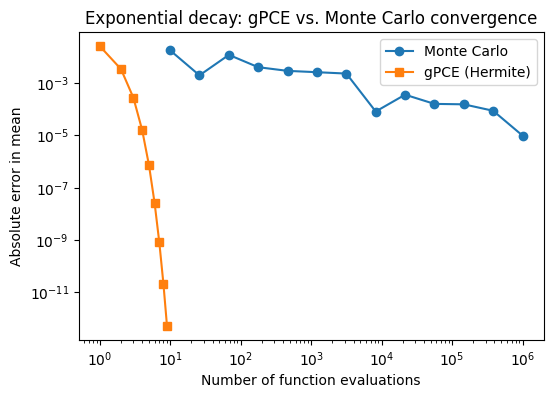

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.loglog(n_conv, mc_mean_err, "o-", label="Monte Carlo")
ax.loglog(orders + 1, np.maximum(pce_mean_err, 1e-16), "s-", label="gPCE (Hermite)")
ax.set_xlabel("Number of function evaluations")
ax.set_ylabel("Absolute error in mean")
ax.set_title("Exponential decay: gPCE vs. Monte Carlo convergence")
ax.legend()
plt.show()

With only $p=8$ (9 Hermite quadrature points) the gPCE mean is accurate to machine precision, while Monte Carlo needs on the order of $10^6$ samples to reach even $10^{-5}$ error — the payoff of matching the polynomial family to the input distribution and representing a genuinely nonlinear response (this one is lognormal-shaped, not close to Gaussian) exactly rather than approximately.

## Example 2: The Ishigami function

The Ishigami function (Ishigami & Homma, 1990) is a standard nonlinear benchmark in the global sensitivity analysis literature, used specifically because its variance decomposition is known in closed form:

$$Y = f(x_1, x_2, x_3) = \sin(x_1) + a\sin^2(x_2) + b\,x_3^4\sin(x_1), \qquad x_i \overset{iid}{\sim} \mathcal U(-\pi, \pi)$$

with the conventional constants $a=7$, $b=0.1$. Because the inputs are uniform rather than Gaussian, the natural basis here is **Legendre**, not Hermite — the Askey-scheme correspondence mentioned above, exercised for the first time in this notebook.

The output variance and its Sobol' decomposition can be derived directly from the trigonometric moments of a uniform variable ($\mathbb{E}[\sin^2]=\tfrac12$, $\mathbb{E}[\sin^4]=\tfrac38$, $\mathbb{E}[x^{2k}]=\pi^{2k}/(2k+1)$):

$$D = \mathrm{Var}(Y) = \frac{a^2}{8} + \frac{b\pi^4}{5} + \frac{b^2\pi^8}{18} + \frac12$$

with first-order and interaction terms

$$D_1 = \frac{b\pi^4}{5} + \frac{b^2\pi^8}{50} + \frac12, \qquad D_2 = \frac{a^2}{8}, \qquad D_3 = 0, \qquad D_{13} = \frac{8b^2\pi^8}{225}$$

($D_{12} = D_{23} = D_{123} = 0$ — $x_2$ enters purely additively, and $x_3$ has no first-order effect at all except through its interaction with $x_1$). These satisfy $D = D_1 + D_2 + D_3 + D_{13}$ exactly, and give the well-known reference values $S_1 \approx 0.314$, $S_2 \approx 0.442$, $S_3 = 0$, $S_{13} \approx 0.244$.

Since `FunctionSpace.tensor` builds an orthonormal tensor-product basis (each factor normalized via `density=True`), the squared PCE coefficients decompose the variance directly by which input variables a given basis function depends on — no extra sampling or Saltelli-style estimator needed, exactly as advertised in the closing remark of this notebook: **the PCE coefficients are the Sobol' indices.**

In [6]:
from archimedes.experimental.approximation import FunctionSpace

a = 7.0
b = 0.1


@arc.compile
def f_ishigami(x):
    x1, x2, x3 = x.T
    return np.sin(x1) + a * np.sin(x2) ** 2 + b * x3**4 * np.sin(x1)


pi = np.pi
D = a**2 / 8 + b * pi**4 / 5 + b**2 * pi**8 / 18 + 0.5
D1 = b * pi**4 / 5 + b**2 * pi**8 / 50 + 0.5
D2 = a**2 / 8
D3 = 0.0
D13 = 8 * b**2 * pi**8 / 225

S1, S2, S3, S13 = D1 / D, D2 / D, D3 / D, D13 / D
print(f"Exact total variance: {D:.6f}")
print(f"Exact Sobol' indices: S1={S1:.4f}  S2={S2:.4f}  S3={S3:.4f}  S13={S13:.4f}")

Exact total variance: 13.844588
Exact Sobol' indices: S1=0.3139  S2=0.4424  S3=0.0000  S13=0.2437


In [7]:
def sobol_indices(coeffs):
    """First-order and (1,3)-interaction Sobol' indices from a tensor
    Legendre expansion's squared, orthonormal coefficients, by which
    variables each multi-index's basis function depends on."""
    total_var = np.sum(coeffs**2) - coeffs[0, 0, 0] ** 2
    support = np.indices(coeffs.shape) > 0

    def index(*dims):
        mask = np.ones(coeffs.shape, dtype=bool)
        for d in range(3):
            mask &= support[d] if d in dims else ~support[d]
        return np.sum(coeffs[mask] ** 2) / total_var

    return total_var, index(0), index(1), index(2), index(0, 2)


orders = [4, 6, 8, 10, 12]
var_err = np.zeros(len(orders))
sobol_est = np.zeros((len(orders), 4))

for i, p in enumerate(orders):
    legendre = FunctionSpace.legendre(n_basis=p + 1, a=-pi, b=pi, density=True)
    fn_space = FunctionSpace.tensor(legendre, legendre, legendre)
    f_pce = fn_space.project(f_ishigami)
    coeffs = f_pce.coefficients.reshape(fn_space.basis.shape)

    total_var, s1, s2, s3, s13 = sobol_indices(coeffs)
    var_err[i] = abs(total_var - D)
    sobol_est[i] = [s1, s2, s3, s13]

    print(
        f"p={p:2d}  var_err={var_err[i]:.3e}  "
        f"S1={s1:.4f}  S2={s2:.4f}  S3={s3:.4f}  S13={s13:.4f}"
    )

p= 4  var_err=4.760e+00  S1=0.2297  S2=0.5920  S3=0.0000  S13=0.1783
p= 6  var_err=1.096e+00  S1=0.2908  S2=0.4834  S3=0.0000  S13=0.2258
p= 8  var_err=4.286e-02  S1=0.3129  S2=0.4441  S3=0.0000  S13=0.2429
p=10  var_err=5.550e-04  S1=0.3139  S2=0.4424  S3=0.0000  S13=0.2437
p=12  var_err=3.125e-06  S1=0.3139  S2=0.4424  S3=0.0000  S13=0.2437


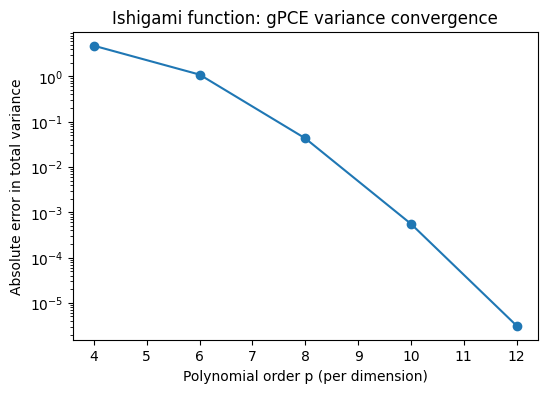

              S1        S2        S3       S13
 exact    0.3139    0.4424    0.0000    0.2437
  p=12    0.3139    0.4424    0.0000    0.2437


In [8]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.semilogy(orders, var_err, "o-")
ax.set_xlabel("Polynomial order p (per dimension)")
ax.set_ylabel("Absolute error in total variance")
ax.set_title("Ishigami function: gPCE variance convergence")
plt.show()

print(f"{'':>6}{'S1':>10}{'S2':>10}{'S3':>10}{'S13':>10}")
print(f"{'exact':>6}{S1:>10.4f}{S2:>10.4f}{S3:>10.4f}{S13:>10.4f}")
print(
    f"{'p=' + str(orders[-1]):>6}{sobol_est[-1, 0]:>10.4f}{sobol_est[-1, 1]:>10.4f}"
    f"{sobol_est[-1, 2]:>10.4f}{sobol_est[-1, 3]:>10.4f}"
)

Notice this needs a much higher polynomial order (p≈10-12 per dimension, i.e. up to $13^3 \approx 2200$ tensor-product quadrature points) than the decay example did — the $x_3^4\sin(x_1)$ term is a genuinely higher-degree, more oscillatory interaction than a lognormal, and tensor-product quadrature cost grows as $(p+1)^d$ in $d$ dimensions. This is the practical tension in gPCE: cheap and spectrally accurate in low dimensions, but the tensor grid becomes the bottleneck as the number of uncertain inputs grows (motivating sparse grids or regression-based "non-intrusive" PCE for larger problems — outside the scope of this notebook).

With both benchmarks confirming the machinery works — spectral convergence to an exact solution, and exact recovery of a known Sobol' decomposition — we turn to a genuine black-box simulation, the apogee-raise burn from the introduction, where no closed-form solution exists and Monte Carlo is the only available check.

## Example 3: Apogee-raise burn dispersion (orbit transfer)

In [9]:
mu = 3.986e14  # Gravitational constant [m^3/s^2]
r_p0 = 6.678e6  # Parking-orbit radius [m]
r_a0 = 4.2164e7  # Initial apogee radius [m]


def propagate_burn(dr_a, dnu, dv_mag, dv_dir):
    # Transfer orbit
    r_a = r_a0 + dr_a  # Actual apogee radius w/ dispersion [m]
    a_t = (r_p0 + r_a) / 2  # Semi-major axis [m]
    e_t = (r_a - r_p0) / (r_a + r_p0)  # Eccentricity
    h = np.sqrt(mu * a_t * (1 - e_t**2))  # Angular momentum [m^2/s]

    nu = np.radians(180) + dnu  # True anomaly at burn [rad]

    # Local radius and radial/tangential velocity at burn
    r = a_t * (1 - e_t**2) / (1 + e_t * np.cos(nu))  # Radius [m]
    v_t = (mu / h) * (1 + e_t * np.cos(nu))  # Tangential velocity [m/s]
    v_r = (mu / h) * e_t * np.sin(nu)  # Radial velocity [m/s]

    # Delta-v for circularization burn
    v_circ = np.sqrt(mu / r_a0)  # Circular velocity at apogee [m/s]
    v_t_nom = (mu / h) * (1 - e_t)  # Nominal tangential velocity at burn [m/s]
    dv_nom = v_circ - v_t_nom  # Nominal delta-v [m/s]

    # Add dispersion to delta-v magnitude and direction
    dv_mag = dv_nom + dv_mag  # Actual delta-v magnitude [m/s]
    dv_r = dv_mag * np.sin(dv_dir)  # Radial component of delta-v [m/s]
    dv_t = dv_mag * np.cos(dv_dir)  # Tangential component of delta-v [m/s]

    # Final orbit after burn
    v_r_f = v_r + dv_r  # Final radial velocity [m/s]
    v_t_f = v_t + dv_t  # Final tangential velocity [m/s]
    E_f = 0.5 * v_r_f**2 + 0.5 * v_t_f**2 - mu / r  # Specific energy [m^2/s^2]
    a_f = -mu / (2 * E_f)  # Semi-major axis [m]
    h_f = r * v_t_f  # Angular momentum [m^2/s]
    e_f = np.sqrt(1 - np.fmin(1, h_f**2 / (mu * a_f)))  # Eccentricity
    r_a_f = a_f * (1 + e_f)  # Final apogee radius [m]
    r_p_f = a_f * (1 - e_f)  # Final perigee radius [m]

    return e_f, r_a_f, r_p_f


@arc.compile(buffered=True)
def f_buffered(dr_a, dnu, dv_mag, dv_dir):
    return propagate_burn(dr_a, dnu, dv_mag, dv_dir)


# Monte Carlo
sigma_dr_a = 100e3  # Apogee radius dispersion [m]
sigma_dnu = np.radians(0.1)  # True anomaly dispersion [rad]
sigma_dv_mag = 5.0  # Delta-v magnitude dispersion [m/s]
sigma_dv_dir = np.radians(0.3)  # Delta-v direction dispersion [rad]

n_samples = 1_000_000
e_samples = np.zeros(n_samples)
r_a_samples = np.zeros(n_samples)
r_p_samples = np.zeros(n_samples)
dr_a_samples = np.random.normal(0, sigma_dr_a, n_samples)
dnu_samples = np.random.normal(0, sigma_dnu, n_samples)
dv_mag_samples = np.random.normal(0, sigma_dv_mag, n_samples)
dv_dir_samples = np.random.normal(0, sigma_dv_dir, n_samples)
for i in range(n_samples):
    dr_a = dr_a_samples[i]
    dnu = 0
    dv_mag = 0
    dv_dir = 0

    e_samples[i], r_a_samples[i], r_p_samples[i] = f_buffered(dr_a, dnu, dv_mag, dv_dir)

In [10]:
r_a_err = r_a_samples - r_a0
r_p_err = r_p_samples - r_a0
max_is_apogee = abs(r_a_err) > abs(r_p_err)
r_err = np.where(max_is_apogee, r_a_err, r_p_err)

In [11]:
print(np.mean(r_err) / 1e3)

0.7821426067815126


In [12]:
print(np.std(r_err) / 1e3)

300.04429921889323


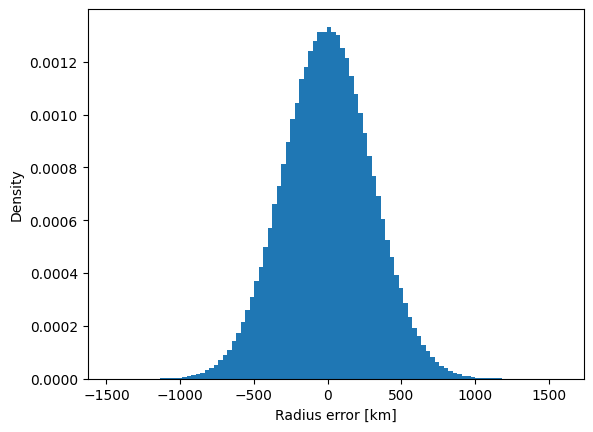

In [13]:

plt.hist(r_err / 1e3, bins=100, density=True)
plt.xlabel("Radius error [km]")
plt.ylabel("Density")
plt.show()

In [14]:
from scipy.stats import kurtosis, skew

print(f"Skewness: {skew(r_err):.4f}")
print(f"Kurtosis: {kurtosis(r_err, fisher=False):.4f}")

Skewness: 0.0179
Kurtosis: 2.9944


Text(0, 0.5, 'Mean radius error [km]')

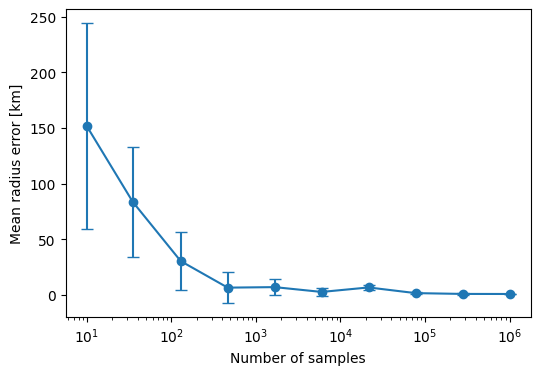

In [15]:
n_conv = np.logspace(1, np.log10(n_samples), num=10, dtype=int)
r_err_mean = np.zeros_like(n_conv, dtype=float)
r_err_std = np.zeros_like(n_conv, dtype=float)
for i, n in enumerate(n_conv):
    r_err_mean[i] = np.mean(r_err[:n])
    r_err_std[i] = np.std(r_err[:n]) / np.sqrt(n)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.errorbar(n_conv, r_err_mean / 1e3, yerr=r_err_std / 1e3, fmt="o-", capsize=4)
ax.set_xscale("log")
ax.set_xlabel("Number of samples")
ax.set_ylabel("Mean radius error [km]")

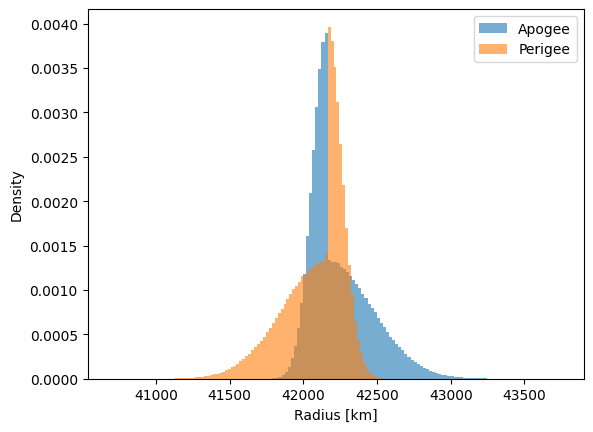

In [16]:
import matplotlib.pyplot as plt

plt.hist(r_a_samples / 1e3, bins=100, density=True, alpha=0.6, label="Apogee")
plt.hist(r_p_samples / 1e3, bins=100, density=True, alpha=0.6, label="Perigee")
plt.legend()
plt.xlabel("Radius [km]")
plt.ylabel("Density")
plt.show()

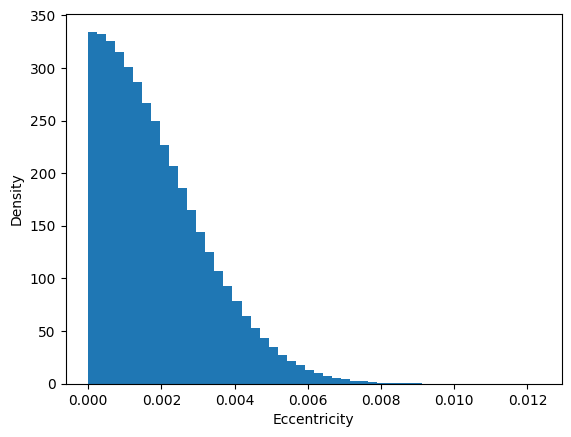

In [17]:
import matplotlib.pyplot as plt

plt.hist(e_samples, bins=50, density=True)
plt.xlabel("Eccentricity")
plt.ylabel("Density")
plt.show()

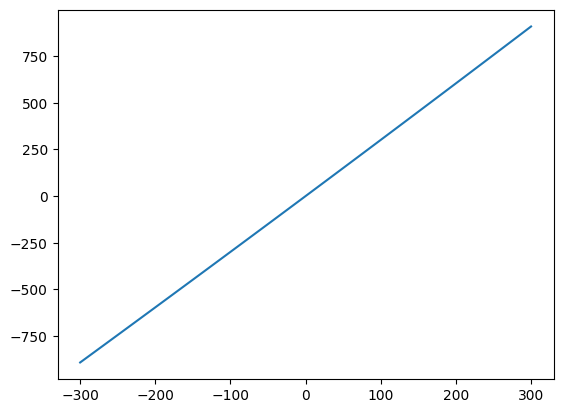

In [18]:
dr_a_sweep = np.linspace(-3 * sigma_dr_a, 3 * sigma_dr_a, 100)
r_err_sweep = np.zeros_like(dr_a_sweep, dtype=float)

for i in range(len(dr_a_sweep)):
    dr_a = dr_a_sweep[i]
    dnu = 0
    dv_mag = 0
    dv_dir = 0

    e, r_a, r_p = propagate_burn(dr_a, dnu, dv_mag, dv_dir)
    r_a_err = r_a - r_a0
    r_p_err = r_p - r_a0
    max_is_apogee = abs(r_a_err) > abs(r_p_err)
    r_err_sweep[i] = r_a_err if max_is_apogee else r_p_err


plt.plot(dr_a_sweep / 1e3, r_err_sweep / 1e3)

In [ ]:
from archimedes.experimental.approximation import FunctionSpace


@arc.compile
def f(dr_a):
    dnu = 0
    dv_mag = 0
    dv_dir = 0
    e, r_a, r_p = propagate_burn(dr_a, dnu, dv_mag, dv_dir)
    r_a_err = r_a - r_a0
    r_p_err = r_p - r_a0
    max_is_apogee = abs(r_a_err) > abs(r_p_err)
    return np.where(max_is_apogee, r_a_err, r_p_err)


p = 3  # Polynomial order
fn_space = FunctionSpace.hermite(
    n_basis=p + 1,
    loc=0.0,
    scale=sigma_dr_a,
    density=True,
)

# Express the random variable as a basis expansion in the function space
# by projecting the function `f` onto the basis functions using
# the quadrature rule for the normalized probabilists' Hermite polynomials.
# Note this is an approximation of `f` itself, not its output distribution.
f_pce = fn_space.project(f)

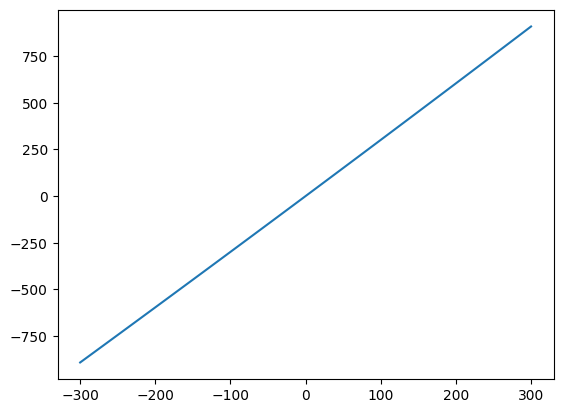

In [20]:
dr_a_sweep = np.linspace(-3 * sigma_dr_a, 3 * sigma_dr_a, 100)
r_err_sweep = f_pce(dr_a_sweep)

plt.plot(dr_a_sweep / 1e3, r_err_sweep / 1e3)

In [21]:
f_pce.coefficients

array([9.48692606e+02, 3.00006750e+05, 1.34167659e+03, 5.51145935e+00])

In [22]:
print(f"Mean: {f_pce.coefficients[0] / 1e3:.4f} m")
print(f"Std: {np.sqrt(np.sum(f_pce.coefficients[1:] ** 2)) / 1e3:.4f} m")

Mean: 0.9487 m
Std: 300.0098 m


## Multivariate distribution

In [23]:
# Monte Carlo
sigma_dr_a = 100e3  # Apogee radius dispersion [m]
sigma_dnu = np.radians(0.1)  # True anomaly dispersion [rad]
sigma_dv_mag = 5.0  # Delta-v magnitude dispersion [m/s]
sigma_dv_dir = np.radians(0.3)  # Delta-v direction dispersion [rad]

n_samples = 1_000_000
e_samples = np.zeros(n_samples)
r_a_samples = np.zeros(n_samples)
r_p_samples = np.zeros(n_samples)
dr_a_samples = np.random.normal(0, sigma_dr_a, n_samples)
dnu_samples = np.random.normal(0, sigma_dnu, n_samples)
dv_mag_samples = np.random.normal(0, sigma_dv_mag, n_samples)
dv_dir_samples = np.random.normal(0, sigma_dv_dir, n_samples)
for i in range(n_samples):
    dr_a = dr_a_samples[i]
    dnu = dnu_samples[i]
    dv_mag = dv_mag_samples[i]
    dv_dir = dv_dir_samples[i]

    e_samples[i], r_a_samples[i], r_p_samples[i] = f_buffered(dr_a, dnu, dv_mag, dv_dir)

In [24]:
r_a_err = r_a_samples - r_a0
r_p_err = r_p_samples - r_a0
max_is_apogee = abs(r_a_err) > abs(r_p_err)
r_err = np.where(max_is_apogee, r_a_err, r_p_err)

print(f"Mean radius error: {np.mean(r_err) / 1e3}")
print(f"Std radius error: {np.std(r_err) / 1e3}")

Mean radius error: 2.2538650951926567
Std radius error: 454.60081140485744


In [25]:
std_err = np.std(r_a_err[:n]) / np.sqrt(n)
print(f"Mean apogee error: {np.mean(r_a_err) / 1e3:.4f} +/- {std_err / 1e3:.4f} km")
print(f"Std apogee error: {np.std(r_a_err) / 1e3:.4f} km")

Mean apogee error: 199.5433 +/- 0.2665 km
Std apogee error: 266.4890 km


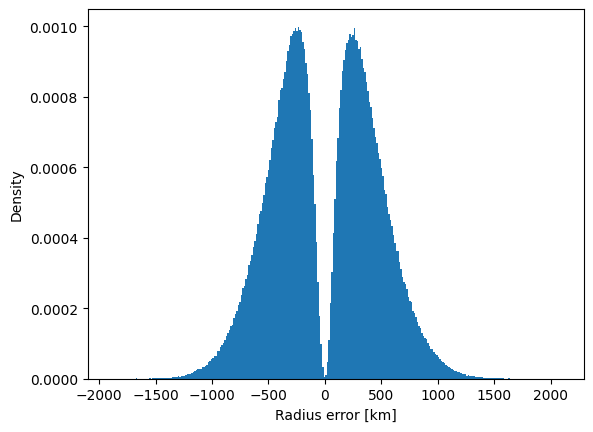

In [26]:
import matplotlib.pyplot as plt

plt.hist(r_err / 1e3, bins=300, density=True)
plt.xlabel("Radius error [km]")
plt.ylabel("Density")
plt.show()

In [27]:
from scipy.stats import kurtosis, skew

print(f"Skewness: {skew(r_err):.4f}")
print(f"Kurtosis: {kurtosis(r_err, fisher=False):.4f}")

Skewness: 0.0248
Kurtosis: 2.3949


Text(0, 0.5, 'Mean radius error [km]')

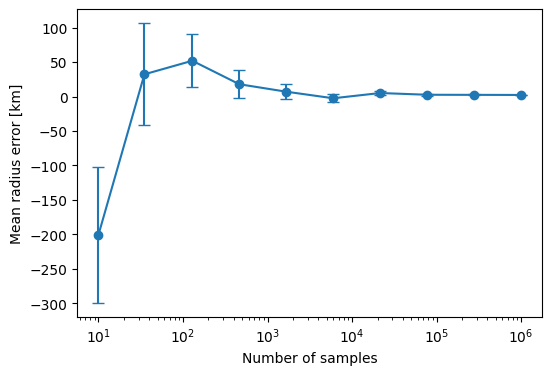

In [28]:
n_conv = np.logspace(1, np.log10(n_samples), num=10, dtype=int)
r_err_mean = np.zeros_like(n_conv, dtype=float)
r_err_std = np.zeros_like(n_conv, dtype=float)
for i, n in enumerate(n_conv):
    r_err_mean[i] = np.mean(r_err[:n])
    r_err_std[i] = np.std(r_err[:n]) / np.sqrt(n)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.errorbar(n_conv, r_err_mean / 1e3, yerr=r_err_std / 1e3, fmt="o-", capsize=4)
ax.set_xscale("log")
ax.set_xlabel("Number of samples")
ax.set_ylabel("Mean radius error [km]")

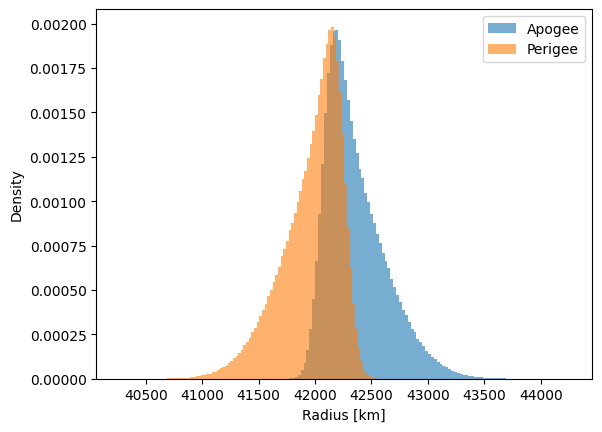

In [29]:
import matplotlib.pyplot as plt

plt.hist(r_a_samples / 1e3, bins=100, density=True, alpha=0.6, label="Apogee")
plt.hist(r_p_samples / 1e3, bins=100, density=True, alpha=0.6, label="Perigee")
plt.legend()
plt.xlabel("Radius [km]")
plt.ylabel("Density")
plt.show()

In [ ]:
from archimedes.experimental.approximation import FunctionSpace


@arc.compile
def f_apogee(dp):
    dr_a, dnu, dv_mag, dv_dir = dp.T
    e, r_a, r_p = propagate_burn(dr_a, dnu, dv_mag, dv_dir)
    return r_a


p = 5  # Polynomial order (could be different per variable)


def hermite_basis(scale):
    return FunctionSpace.hermite(n_basis=p + 1, loc=0.0, scale=scale, density=True)


# The full space is the tensor product of a 1D Hermite space per random variable
fn_space = FunctionSpace.tensor(
    hermite_basis(sigma_dr_a),
    hermite_basis(sigma_dnu),
    hermite_basis(sigma_dv_mag),
    hermite_basis(sigma_dv_dir),
)

# Express the random variable as a basis expansion in the function space
# by projecting the function `f_apogee` onto the basis functions using
# the quadrature rule for the normalized probabilists' Hermite polynomials.
# Note this is an approximation of `f_apogee` itself, not its output distribution.
f_pce = fn_space.project(f_apogee)

In [31]:
len(f_pce.coefficients)

1296

In [32]:
print(f"Mean apogee error: {(f_pce.coefficients[0] - r_a0) / 1e3:.4f} km")
print(f"Std apogee error: {np.sqrt(np.sum(f_pce.coefficients[1:] ** 2)) / 1e3:.4f} km")

Mean apogee error: 197.8966 km
Std apogee error: 267.5722 km


In [33]:
fn_space.basis

TensorBasis(bases=(OrthogonalPolynomialBasis(measure=<archimedes.measure._hermite.ProbabilistsHermiteMeasure object at 0x11534ef90>, n_basis=6, density=True), OrthogonalPolynomialBasis(measure=<archimedes.measure._hermite.ProbabilistsHermiteMeasure object at 0x1144a0aa0>, n_basis=6, density=True), OrthogonalPolynomialBasis(measure=<archimedes.measure._hermite.ProbabilistsHermiteMeasure object at 0x115939790>, n_basis=6, density=True), OrthogonalPolynomialBasis(measure=<archimedes.measure._hermite.ProbabilistsHermiteMeasure object at 0x11593b470>, n_basis=6, density=True)))

In this case you could just as well do the polynomial chaos expansion in plain NumPy/SciPy or a specialized toolkit like [chaospy](https://chaospy.readthedocs.io/en/master/), since it's a non-intrusive algorithm that just requires sampling the black-box `arc.compile`d propagator function, and the PCE coefficients themselves give you the Sobol indices directly.
However, combining this with Archimedes' autodiff capabilities opens the door to interesting uncertainty-aware algorithms.
For instance, you could use PCE to estimate the mean and variance of some quantity of interest and then use this to optimize over deterministic design variables.